Note: The dataset was uploaded directly into the Colab environment to ensure the notebook runs correctly

## **DIABETES PREDICTION ANALYSIS PROJECT**
**Observation:**
All required libraries are imported to prepare the environment for diabetes prediction. Pandas and NumPy are used for data handling and numerical operations, while Matplotlib and Seaborn support data visualisation. Scikit-learn tools are included for data preprocessing, model training, and evaluation. Multiple machine learning models and performance metrics are selected to enable comparison and ensure reliable predictions.

In [2]:
# ============================================
# DIABETES PREDICTION ANALYSIS PROJECT
# ============================================

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score, GridSearchCV
import warnings
warnings.filterwarnings('ignore')

# Set style for visualisations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## **1. LOAD AND INITIAL EXPLORATION**
**Observation:**
In this step, the diabetes dataset is loaded, and an initial inspection is conducted to assess its structure and quality. The dataset size, column names, data types, and missing values are examined to identify any potential data issues. The info() function is used to confirm data types and memory usage. Rows containing missing values are then removed to ensure the dataset is clean and suitable for further analysis and model training.


In [3]:
# ============================================
# 1. LOAD AND INITIAL EXPLORATION
# ============================================

# Load the dataset
df = pd.read_csv('diabetes_extended_noisy.csv')

print("="*50)
print("DATASET OVERVIEW")
print("="*50)
print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nDataset Info:")
df.info()
df=df.dropna()

DATASET OVERVIEW
Dataset Shape: (798, 11)

Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'PhysicalActivityLevel', 'FamilyHistory']

Data Types:
Pregnancies                   int64
Glucose                     float64
BloodPressure                 int64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
PhysicalActivityLevel         int64
FamilyHistory                object
dtype: object

Missing Values:
Pregnancies                   0
Glucose                       0
BloodPressure                 0
SkinThickness                16
Insulin                      16
BMI                          16
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
PhysicalActivityLevel         0
FamilyHistory        

## **2. EXPLORATORY DATA ANALYSIS:**
**Observation:**
Exploratory data analysis is performed to understand the dataset better and identify patterns related to diabetes. Summary statistics are used to examine the distribution of numerical features. The target variable is analysed to check the balance between diabetic and non-diabetic cases. Feature distributions are visualised to observe spread and skewness, and zero values in key medical features are reviewed as possible missing data. Correlation analysis helps identify relationships between features and the outcome, while categorical features and boxplots are used to explore their impact and detect potential outliers. This step helps guide later preprocessing and model development decisions.



EXPLORATORY DATA ANALYSIS

1. BASIC STATISTICS
------------------------------
Numerical Features Summary:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   359.000000  359.000000     359.000000     359.000000  359.000000   
mean      3.757660  123.211699      68.869081      23.197772  101.381616   
std       3.461648   31.813348      18.020848      15.436024  120.845309   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000  100.000000      62.000000      12.500000    0.000000   
50%       2.000000  119.000000      72.000000      26.000000   76.000000   
75%       6.000000  142.000000      80.000000      33.000000  160.000000   
max      17.000000  199.000000     110.000000      99.000000  744.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  \
count  359.000000                359.000000  359.000000  359.000000   
mean    32.848747                  0.732482   33.479109    0.41225

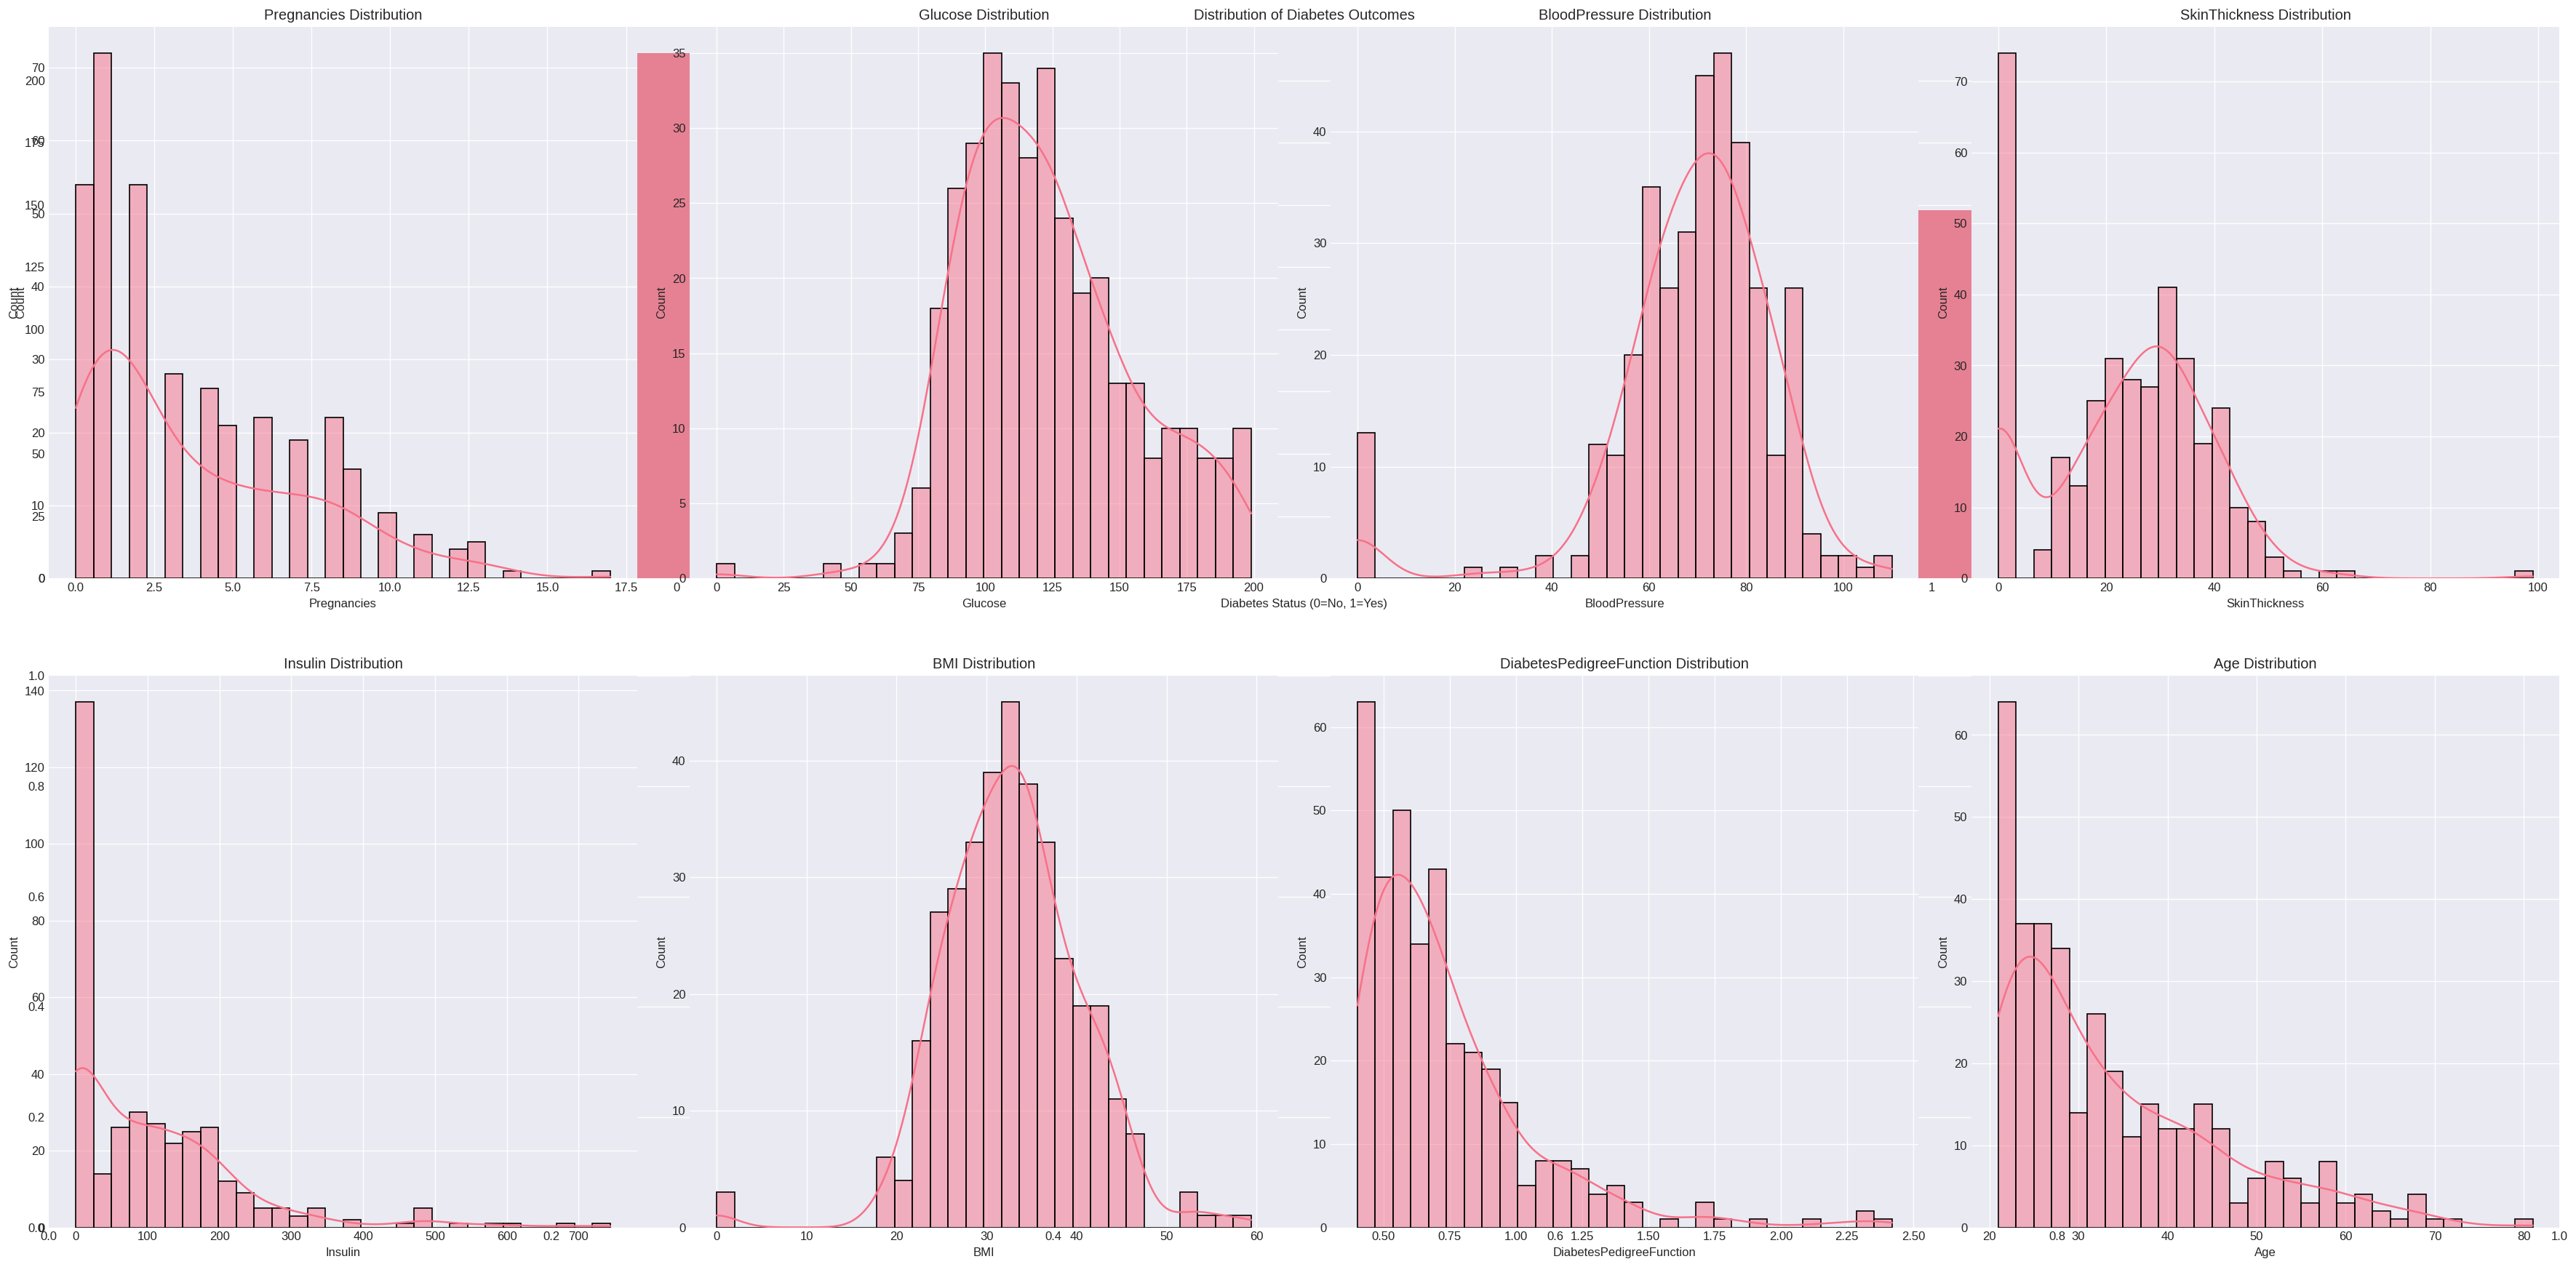


4. MISSING VALUES ANALYSIS
------------------------------
Glucose: 1 zeros (0.28%)
BloodPressure: 13 zeros (3.62%)
SkinThickness: 74 zeros (20.61%)
Insulin: 132 zeros (36.77%)
BMI: 3 zeros (0.84%)

5. CORRELATION ANALYSIS
------------------------------


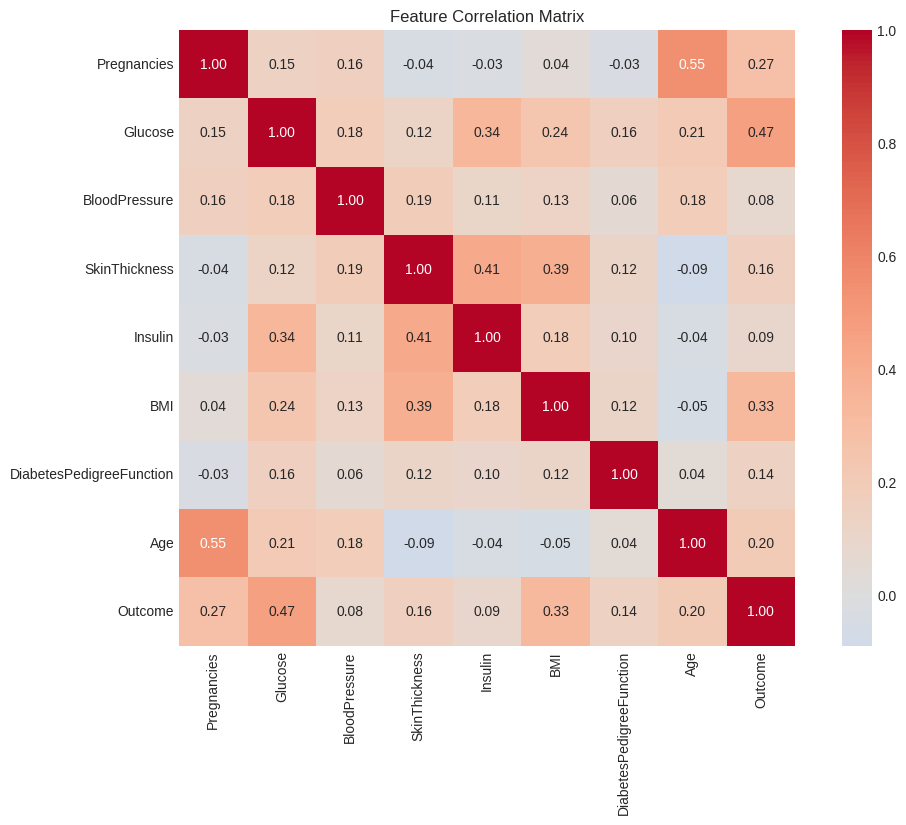


Top Correlations with Outcome:
Outcome                     1.000000
Glucose                     0.465559
BMI                         0.327181
Pregnancies                 0.273161
Age                         0.201583
SkinThickness               0.159961
DiabetesPedigreeFunction    0.139687
Insulin                     0.090152
BloodPressure               0.077789
Name: Outcome, dtype: float64

6. CATEGORICAL FEATURES ANALYSIS
------------------------------

PhysicalActivityLevel:
PhysicalActivityLevel
2    220
1    135
3      4
Name: count, dtype: int64


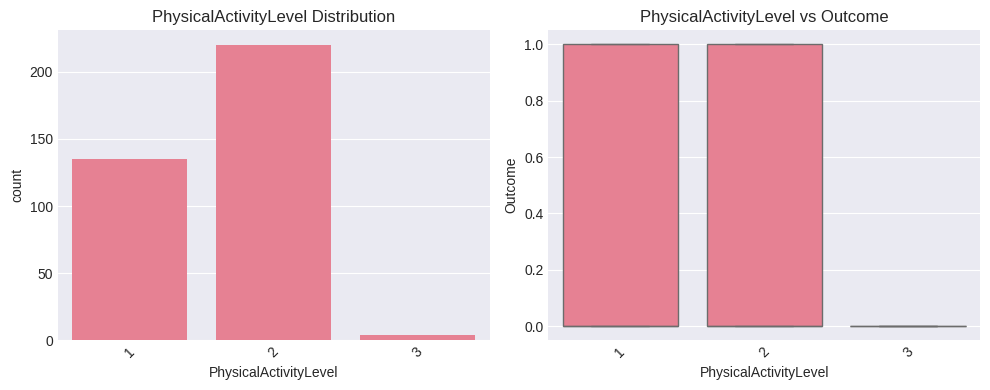


FamilyHistory:
FamilyHistory
Moderate    251
Strong      108
Name: count, dtype: int64


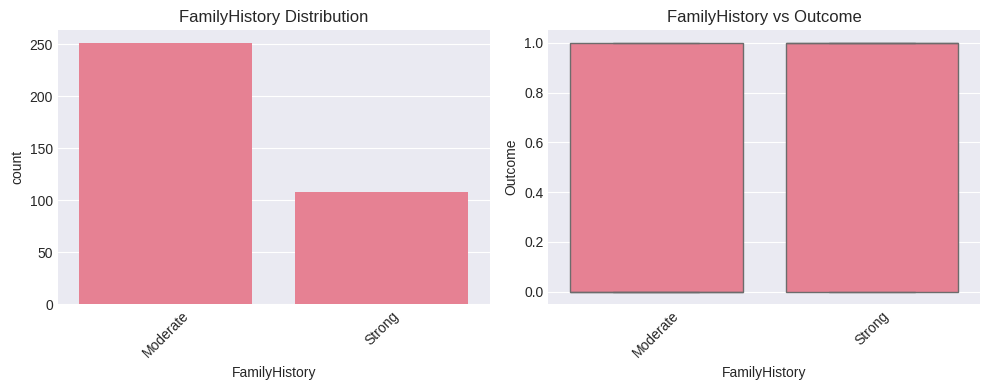


7. OUTLIER DETECTION
------------------------------


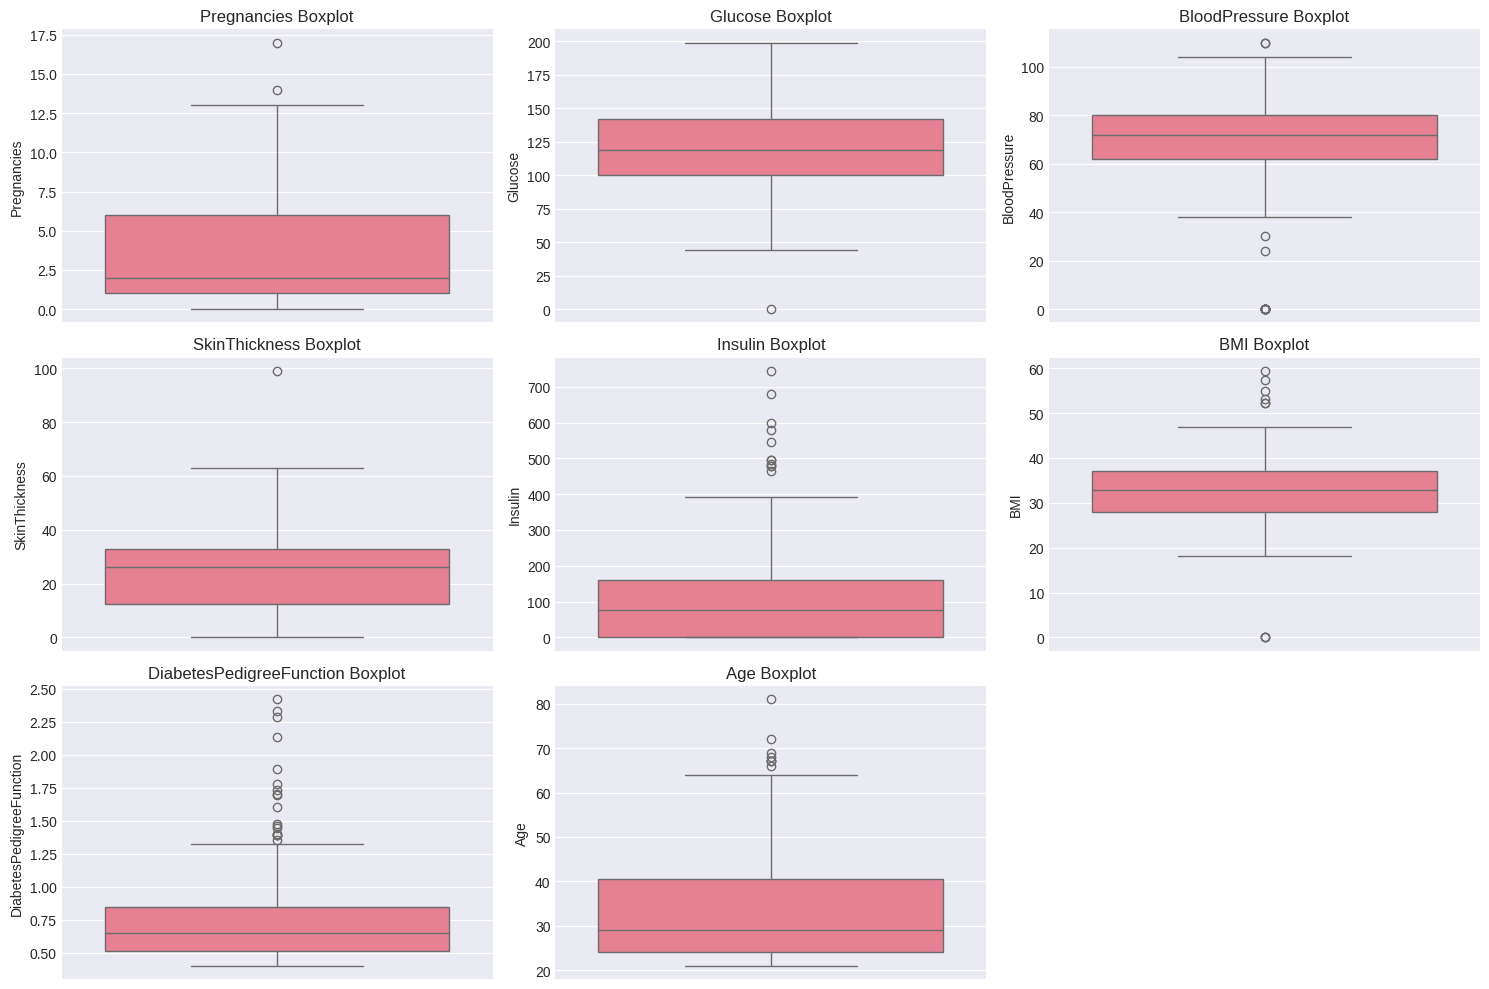

Pregnancies: 2 potential outliers
Glucose: 1 potential outliers
BloodPressure: 17 potential outliers
SkinThickness: 1 potential outliers
Insulin: 11 potential outliers
BMI: 9 potential outliers
DiabetesPedigreeFunction: 18 potential outliers
Age: 8 potential outliers


In [4]:
# ============================================
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================

def perform_eda(df):
    """Perform comprehensive EDA"""

    print("\n" + "="*50)
    print("EXPLORATORY DATA ANALYSIS")
    print("="*50)

    # 2.1 Basic Statistics
    print("\n1. BASIC STATISTICS")
    print("-"*30)
    print("Numerical Features Summary:")
    print(df.describe())

    # 2.2 Target Distribution
    print("\n2. TARGET DISTRIBUTION (Outcome)")
    print("-"*30)
    outcome_counts = df['Outcome'].value_counts()
    outcome_percent = df['Outcome'].value_counts(normalize=True) * 100
    print(f"Non-Diabetic (0): {outcome_counts[0]} ({outcome_percent[0]:.2f}%)")
    print(f"Diabetic (1): {outcome_counts[1]} ({outcome_percent[1]:.2f}%)")

    # Visualize target distribution
    plt.figure(figsize=(30, 15),dpi = 120)
    plt.subplot(2, 1, 1)
    sns.countplot(x='Outcome', data=df)
    plt.title('Distribution of Diabetes Outcomes')
    plt.xlabel('Diabetes Status (0=No, 1=Yes)')
    plt.ylabel('Count')

    # 2.3 Feature Distributions
    print("\n3. FEATURE DISTRIBUTIONS")
    print("-"*30)

    # Select numerical features (excluding Outcome)
    numerical_features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                         'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

    # Create distribution plots
    plt.subplot(2, 1, 2)
    for i, feature in enumerate(numerical_features[:4], 1):
        plt.subplot(2, 4, i)
        sns.histplot(df[feature], kde=True, bins=30)
        plt.title(f'{feature} Distribution')
        plt.tight_layout()

    for i, feature in enumerate(numerical_features[4:], 5):
        plt.subplot(2, 4, i)
        sns.histplot(df[feature], kde=True, bins=30)
        plt.title(f'{feature} Distribution')
        plt.tight_layout()

    plt.show()

    # 2.4 Missing Values Analysis
    print("\n4. MISSING VALUES ANALYSIS")
    print("-"*30)

    # Check for zeros that might represent missing values
    medical_features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
    zero_counts = {}
    for feature in medical_features:
        zero_count = (df[feature] == 0).sum()
        zero_percentage = (zero_count / len(df)) * 100
        zero_counts[feature] = zero_count
        print(f"{feature}: {zero_count} zeros ({zero_percentage:.2f}%)")

    # 2.5 Correlation Analysis
    print("\n5. CORRELATION ANALYSIS")
    print("-"*30)

    # Calculate correlation matrix
    correlation_matrix = df[numerical_features + ['Outcome']].corr()

    plt.figure(figsize=(12, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
                square=True, fmt='.2f')
    plt.title('Feature Correlation Matrix')
    plt.show()

    # Top correlations with Outcome
    outcome_corr = correlation_matrix['Outcome'].sort_values(ascending=False)
    print("\nTop Correlations with Outcome:")
    print(outcome_corr)

    # 2.6 Categorical Features Analysis
    print("\n6. CATEGORICAL FEATURES ANALYSIS")
    print("-"*30)

    categorical_features = ['PhysicalActivityLevel', 'FamilyHistory']

    for feature in categorical_features:
        print(f"\n{feature}:")
        print(df[feature].value_counts())

        # Visualization
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        sns.countplot(x=feature, data=df)
        plt.title(f'{feature} Distribution')
        plt.xticks(rotation=45)

        plt.subplot(1, 2, 2)
        sns.boxplot(x=feature, y='Outcome', data=df)
        plt.title(f'{feature} vs Outcome')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    # 2.7 Outlier Detection
    print("\n7. OUTLIER DETECTION")
    print("-"*30)

    plt.figure(figsize=(15, 10))
    for i, feature in enumerate(numerical_features, 1):
        plt.subplot(3, 3, i)
        sns.boxplot(y=df[feature])
        plt.title(f'{feature} Boxplot')
        plt.tight_layout()

    plt.show()

    # Identify potential outliers using IQR method
    for feature in numerical_features:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
        print(f"{feature}: {len(outliers)} potential outliers")

    return zero_counts

# Execute EDA
zero_counts = perform_eda(df)

## **3. DATA PREPARATION FOR MACHINE LEARNING**
**Observation:**
In this stage, the data is cleaned and prepared for machine learning. Zero values in important medical features are treated as missing where appropriate, and extremely noisy values are corrected to minimise their influence on the models. Missing values are filled using the median to reduce the effect of outliers. Categorical variables are converted into numerical form so machine learning algorithms can use them. New features, such as BMI categories, age groups, and metabolic risk indicators, are created to capture clinically meaningful information. Outliers are further controlled using winsorisation, and a final set of relevant features is selected for model training.


In [5]:
# ============================================
# 3. DATA PREPARATION FOR ML
# ============================================

def prepare_data(df):
    """Clean and prepare data for machine learning"""

    print("\n" + "="*50)
    print("DATA PREPARATION")
    print("="*50)

    # Create a copy to avoid modifying original
    df_clean = df.copy()

    # 3.1 Handle Missing/Invalid Values
    print("\n1. HANDLING MISSING/INVALID VALUES")
    print("-"*30)

    # Identify medical columns where 0 might indicate missing data
    medical_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

    # Replace 0 with NaN in medical columns (except Pregnancies where 0 is valid)
    for col in medical_cols:
        df_clean[col] = df_clean[col].replace(0, np.nan)
        missing_pct = df_clean[col].isnull().sum() / len(df_clean) * 100
        print(f"{col}: {df_clean[col].isnull().sum()} missing values ({missing_pct:.2f}%)")

    # 3.2 Handle Specific Noisy Entries
    print("\n2. HANDLING NOISY ENTRIES")
    print("-"*30)

    # Fix the extreme outlier in Glucose
    extreme_glucose = df_clean[df_clean['Glucose'] > 400]
    print(f"Extreme Glucose values found: {len(extreme_glucose)}")

    # Replace extreme values with median
    glucose_median = df_clean['Glucose'].median()
    df_clean.loc[df_clean['Glucose'] > 400, 'Glucose'] = glucose_median

    # 3.3 Impute Missing Values
    print("\n3. IMPUTING MISSING VALUES")
    print("-"*30)

    # Strategy: Use median for medical features (robust to outliers)
    imputer = SimpleImputer(strategy='median')

    # Apply imputation to medical features
    df_clean[medical_cols] = imputer.fit_transform(df_clean[medical_cols])
    print("Missing values imputed using median strategy")

    # 3.4 Handle Categorical Variables
    print("\n4. ENCODING CATEGORICAL VARIABLES")
    print("-"*30)

    # Encode FamilyHistory
    family_mapping = {'None': 0, 'Moderate': 1, 'Strong': 2}
    df_clean['FamilyHistory_encoded'] = df_clean['FamilyHistory'].map(family_mapping)

    # Handle PhysicalActivityLevel (ensure it's numeric)
    df_clean['PhysicalActivityLevel'] = pd.to_numeric(df_clean['PhysicalActivityLevel'], errors='coerce')

    # Fill any NaN in PhysicalActivityLevel with mode
    if df_clean['PhysicalActivityLevel'].isnull().sum() > 0:
        mode_val = df_clean['PhysicalActivityLevel'].mode()[0]
        df_clean['PhysicalActivityLevel'] = df_clean['PhysicalActivityLevel'].fillna(mode_val)

    print("Categorical variables encoded successfully")

    # 3.5 Feature Engineering
    print("\n5. FEATURE ENGINEERING")
    print("-"*30)

    # Create BMI categories
    df_clean['BMI_Category'] = pd.cut(df_clean['BMI'],
                                      bins=[0, 18.5, 25, 30, 35, 40, 100],
                                      labels=['Underweight', 'Normal', 'Overweight',
                                              'Obese I', 'Obese II', 'Obese III'])

    # Create age groups
    df_clean['Age_Group'] = pd.cut(df_clean['Age'],
                                   bins=[0, 30, 40, 50, 60, 100],
                                   labels=['<30', '30-40', '40-50', '50-60', '60+'])

    # Create insulin resistance indicator
    df_clean['High_Insulin'] = (df_clean['Insulin'] > df_clean['Insulin'].quantile(0.75)).astype(int)

    # Create metabolic syndrome indicator (simplified)
    df_clean['Metabolic_Risk'] = ((df_clean['Glucose'] > 140) |
                                  (df_clean['BloodPressure'] > 90) |
                                  (df_clean['BMI'] > 30)).astype(int)

    print("New features created:")
    print("- BMI_Category")
    print("- Age_Group")
    print("- High_Insulin")
    print("- Metabolic_Risk")

    # 3.6 Handle Outliers (Winsorization)
    print("\n6. HANDLING OUTLIERS")
    print("-"*30)

    def winsorize(series, limits=[0.05, 0.05]):
        """Winsorize extreme values"""
        lower = series.quantile(limits[0])
        upper = series.quantile(1 - limits[1])
        return series.clip(lower, upper)

    # Apply winsorization to key features
    features_to_winsorize = ['Glucose', 'Insulin', 'BMI', 'DiabetesPedigreeFunction']
    for feature in features_to_winsorize:
        df_clean[feature] = winsorize(df_clean[feature])
        print(f"{feature}: Winsorized (5% each tail)")

    # 3.7 Final Feature Selection
    print("\n7. FINAL FEATURE SELECTION")
    print("-"*30)

    # Select features for modeling
    features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age',
                'PhysicalActivityLevel', 'FamilyHistory_encoded',
                'High_Insulin', 'Metabolic_Risk']

    X = df_clean[features]
    y = df_clean['Outcome']

    print(f"Selected {len(features)} features for modeling")
    print(f"Target variable shape: {y.shape}")

    return X, y, df_clean

# Prepare the data
X, y, df_clean = prepare_data(df)



DATA PREPARATION

1. HANDLING MISSING/INVALID VALUES
------------------------------
Glucose: 1 missing values (0.28%)
BloodPressure: 13 missing values (3.62%)
SkinThickness: 74 missing values (20.61%)
Insulin: 132 missing values (36.77%)
BMI: 3 missing values (0.84%)

2. HANDLING NOISY ENTRIES
------------------------------
Extreme Glucose values found: 0

3. IMPUTING MISSING VALUES
------------------------------
Missing values imputed using median strategy

4. ENCODING CATEGORICAL VARIABLES
------------------------------
Categorical variables encoded successfully

5. FEATURE ENGINEERING
------------------------------
New features created:
- BMI_Category
- Age_Group
- High_Insulin
- Metabolic_Risk

6. HANDLING OUTLIERS
------------------------------
Glucose: Winsorized (5% each tail)
Insulin: Winsorized (5% each tail)
BMI: Winsorized (5% each tail)
DiabetesPedigreeFunction: Winsorized (5% each tail)

7. FINAL FEATURE SELECTION
------------------------------
Selected 12 features for mo

## **4. DATA SPLITTING**
**Observation:**
The dataset is split into training, validation, and testing sets using a 70:15:15 ratio. Stratified sampling is applied to maintain the original class distribution of the diabetes outcome in each subset. The training set is used to build the models, the validation set supports model tuning and comparison, and the test set is reserved for final, unbiased performance evaluation. This approach helps reduce overfitting and improves the reliability of the results.


In [6]:
# ============================================
# 4. DATA SPLITTING
# ============================================

print("\n" + "="*50)
print("DATA SPLITTING STRATEGY")
print("="*50)

# Split: 70% training, 15% validation, 15% testing
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)  # 0.1765 * 0.85 ≈ 0.15

print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\nClass distribution in training set:")
print(y_train.value_counts(normalize=True))
print(f"\nClass distribution in validation set:")
print(y_val.value_counts(normalize=True))
print(f"\nClass distribution in testing set:")
print(y_test.value_counts(normalize=True))


DATA SPLITTING STRATEGY
Training set: 251 samples (69.9%)
Validation set: 54 samples (15.0%)
Testing set: 54 samples (15.0%)

Class distribution in training set:
Outcome
0    0.585657
1    0.414343
Name: proportion, dtype: float64

Class distribution in validation set:
Outcome
0    0.592593
1    0.407407
Name: proportion, dtype: float64

Class distribution in testing set:
Outcome
0    0.592593
1    0.407407
Name: proportion, dtype: float64


## **5. FEATURE SCALING**
**Observation:**
Feature scaling is applied to ensure that all input variables are on a similar scale. Both StandardScaler and MinMaxScaler are used to support different types of machine learning models, particularly those sensitive to feature magnitude. The scalers are fitted using the training data and then applied to the validation and test sets to avoid data leakage. This step helps improve model performance and stability.



In [7]:
# ============================================
# 5. FEATURE SCALING
# ============================================

print("\n" + "="*50)
print("FEATURE SCALING")
print("="*50)

# Initialize scalers
scaler_standard = StandardScaler()
scaler_minmax = MinMaxScaler()

# Scale features
X_train_scaled_std = scaler_standard.fit_transform(X_train)
X_val_scaled_std = scaler_standard.transform(X_val)
X_test_scaled_std = scaler_standard.transform(X_test)

X_train_scaled_mm = scaler_minmax.fit_transform(X_train)
X_val_scaled_mm = scaler_minmax.transform(X_val)
X_test_scaled_mm = scaler_minmax.transform(X_test)

print("Features scaled using:")
print("1. StandardScaler (zero mean, unit variance)")
print("2. MinMaxScaler (range [0, 1])")



FEATURE SCALING
Features scaled using:
1. StandardScaler (zero mean, unit variance)
2. MinMaxScaler (range [0, 1])


## **6. MACHINE LEARNING MODEL DEVELOPMENT**
**Observation:**
In this section, several machine learning models are trained and evaluated, including Logistic Regression, Decision Tree, and Support Vector Machine. Each model is trained on scaled training data and evaluated on both the training and validation sets to compare performance and identify potential overfitting. Performance is assessed using accuracy, precision, recall, and F1-score to provide a balanced evaluation. Hyperparameter tuning is carried out using Grid Search to improve the Decision Tree model, and cross-validation is used to assess model consistency and generalisation. This process supports selecting the most effective model for diabetes prediction.


In [8]:
# ============================================
# 6. MACHINE LEARNING MODEL DEVELOPMENT
# ============================================

def train_and_evaluate_model(model, X_train, X_val, y_train, y_val, model_name):
    """Train and evaluate a single model"""

    # Train the model
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    # Calculate metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    val_accuracy = accuracy_score(y_val, y_val_pred)

    train_precision = precision_score(y_train, y_train_pred, zero_division=0)
    val_precision = precision_score(y_val, y_val_pred, zero_division=0)

    train_recall = recall_score(y_train, y_train_pred, zero_division=0)
    val_recall = recall_score(y_val, y_val_pred, zero_division=0)

    train_f1 = f1_score(y_train, y_train_pred, zero_division=0)
    val_f1 = f1_score(y_val, y_val_pred, zero_division=0)

    # Return results
    results = {
        'model': model,
        'model_name': model_name,
        'train_accuracy': train_accuracy,
        'val_accuracy': val_accuracy,
        'train_precision': train_precision,
        'val_precision': val_precision,
        'train_recall': train_recall,
        'val_recall': val_recall,
        'train_f1': train_f1,
        'val_f1': val_f1
    }

    return results

def print_model_results(results):
    """Print model evaluation results"""

    print(f"\n{results['model_name']} Results:")
    print("-"*40)
    print(f"{'Metric':<15} {'Training':<12} {'Validation':<12}")
    print(f"{'-'*15} {'-'*12} {'-'*12}")
    print(f"{'Accuracy':<15} {results['train_accuracy']:.4f}      {results['val_accuracy']:.4f}")
    print(f"{'Precision':<15} {results['train_precision']:.4f}      {results['val_precision']:.4f}")
    print(f"{'Recall':<15} {results['train_recall']:.4f}      {results['val_recall']:.4f}")
    print(f"{'F1-Score':<15} {results['train_f1']:.4f}      {results['val_f1']:.4f}")

    # Check for overfitting
    accuracy_diff = abs(results['train_accuracy'] - results['val_accuracy'])
    if accuracy_diff > 0.1:
        print(f"⚠️  Warning: Potential overfitting (accuracy diff: {accuracy_diff:.3f})")

    return results

print("\n" + "="*50)
print("MODEL TRAINING AND EVALUATION")
print("="*50)

# 6.1 Initialise Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Support Vector Machine': SVC(kernel='rbf', random_state=42, probability=True)
}

# 6.2 Train and Evaluate Models (using StandardScaler)
print("\nMODEL PERFORMANCE (StandardScaler):")
print("-"*50)

all_results = []
for name, model in models.items():
    results = train_and_evaluate_model(
        model, X_train_scaled_std, X_val_scaled_std, y_train, y_val, name
    )
    all_results.append(print_model_results(results))

# 6.3 Hyperparameter Tuning (Example: Decision Tree)
print("\n" + "="*50)
print("HYPERPARAMETER TUNING - DECISION TREE")
print("="*50)

# Define parameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Perform Grid Search
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_scaled_std, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# 6.4 Train Best Model
best_dt = grid_search.best_estimator_
best_dt_results = train_and_evaluate_model(
    best_dt, X_train_scaled_std, X_val_scaled_std, y_train, y_val, "Decision Tree (Tuned)"
)
print_model_results(best_dt_results)

# 6.5 Cross-Validation
print("\n" + "="*50)
print("CROSS-VALIDATION RESULTS")
print("="*50)

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_scaled_std, y_train, cv=5, scoring='accuracy')
    print(f"{name} - CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")


MODEL TRAINING AND EVALUATION

MODEL PERFORMANCE (StandardScaler):
--------------------------------------------------

Logistic Regression Results:
----------------------------------------
Metric          Training     Validation  
--------------- ------------ ------------
Accuracy        0.7928      0.8148
Precision       0.7826      0.7727
Recall          0.6923      0.7727
F1-Score        0.7347      0.7727

Decision Tree Results:
----------------------------------------
Metric          Training     Validation  
--------------- ------------ ------------
Accuracy        0.8725      0.7407
Precision       0.7951      0.6667
Recall          0.9327      0.7273
F1-Score        0.8584      0.6957
⚠️  Warning: Potential overfitting (accuracy diff: 0.132)

Support Vector Machine Results:
----------------------------------------
Metric          Training     Validation  
--------------- ------------ ------------
Accuracy        0.8486      0.8148
Precision       0.8667      0.7500
Recall     

## **7. FINAL MODEL EVALUATION ON TEST SET**
**Observation:**
In this final stage, the trained models are evaluated using the unseen test dataset to assess how well they perform on new data. Performance is measured using accuracy, precision, recall, and F1-score, with particular focus on recall due to its importance in correctly identifying diabetic cases. A confusion matrix and classification report are also generated to give a clear breakdown of correct and incorrect predictions. This step provides a realistic indication of each models ability to generalise beyond the training data.


In [9]:
# ============================================
# 7. FINAL MODEL EVALUATION ON TEST SET
# ============================================

print("\n" + "="*50)
print("FINAL EVALUATION ON TEST SET")
print("="*50)

def evaluate_on_test_set(model, X_test, y_test, model_name):
    """Evaluate model on test set"""

    # Predictions
    y_test_pred = model.predict(X_test)

    # Calculate metrics
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, zero_division=0)
    test_recall = recall_score(y_test, y_test_pred, zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, zero_division=0)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)

    print(f"\n{model_name} - Test Set Performance:")
    print(f"{'-'*40}")
    print(f"Accuracy:  {test_accuracy:.4f}")
    print(f"Precision: {test_precision:.4f}")
    print(f"Recall:    {test_recall:.4f}")
    print(f"F1-Score:  {test_f1:.4f}")

    print(f"\nConfusion Matrix:")
    print(cm)

    # Classification report
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_test_pred))

    return {
        'test_accuracy': test_accuracy,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_f1': test_f1,
        'confusion_matrix': cm
    }

# Evaluate all models on test set
test_results = {}
for name, model in models.items():
    test_results[name] = evaluate_on_test_set(model, X_test_scaled_std, y_test, name)



FINAL EVALUATION ON TEST SET

Logistic Regression - Test Set Performance:
----------------------------------------
Accuracy:  0.7037
Precision: 0.6154
Recall:    0.7273
F1-Score:  0.6667

Confusion Matrix:
[[22 10]
 [ 6 16]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.69      0.73        32
           1       0.62      0.73      0.67        22

    accuracy                           0.70        54
   macro avg       0.70      0.71      0.70        54
weighted avg       0.72      0.70      0.71        54


Decision Tree - Test Set Performance:
----------------------------------------
Accuracy:  0.6481
Precision: 0.5455
Recall:    0.8182
F1-Score:  0.6545

Confusion Matrix:
[[17 15]
 [ 4 18]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.53      0.64        32
           1       0.55      0.82      0.65        22

    accuracy                           0.65  

## **8. MODEL COMPARISON AND VISUALIATION**
**Observation:**
Here, the performance of all models is compared using results from the training, validation, and test sets. A summary table is created to present key metrics such as accuracy, precision, recall, and F1-score, making it easier to compare models side by side. Visualisations are used to highlight differences in overall performance, the balance between precision and recall, and potential overfitting by comparing training and validation accuracy. This comparison helps identify the most reliable model for diabetes prediction.



MODEL COMPARISON SUMMARY

Model Performance Comparison:
                 Model  Train_Accuracy  Val_Accuracy  Test_Accuracy  Test_Precision  Test_Recall  Test_F1
   Logistic Regression        0.792829      0.814815       0.703704        0.615385     0.727273 0.666667
         Decision Tree        0.872510      0.740741       0.648148        0.545455     0.818182 0.654545
Support Vector Machine        0.848606      0.814815       0.666667        0.576923     0.681818 0.625000


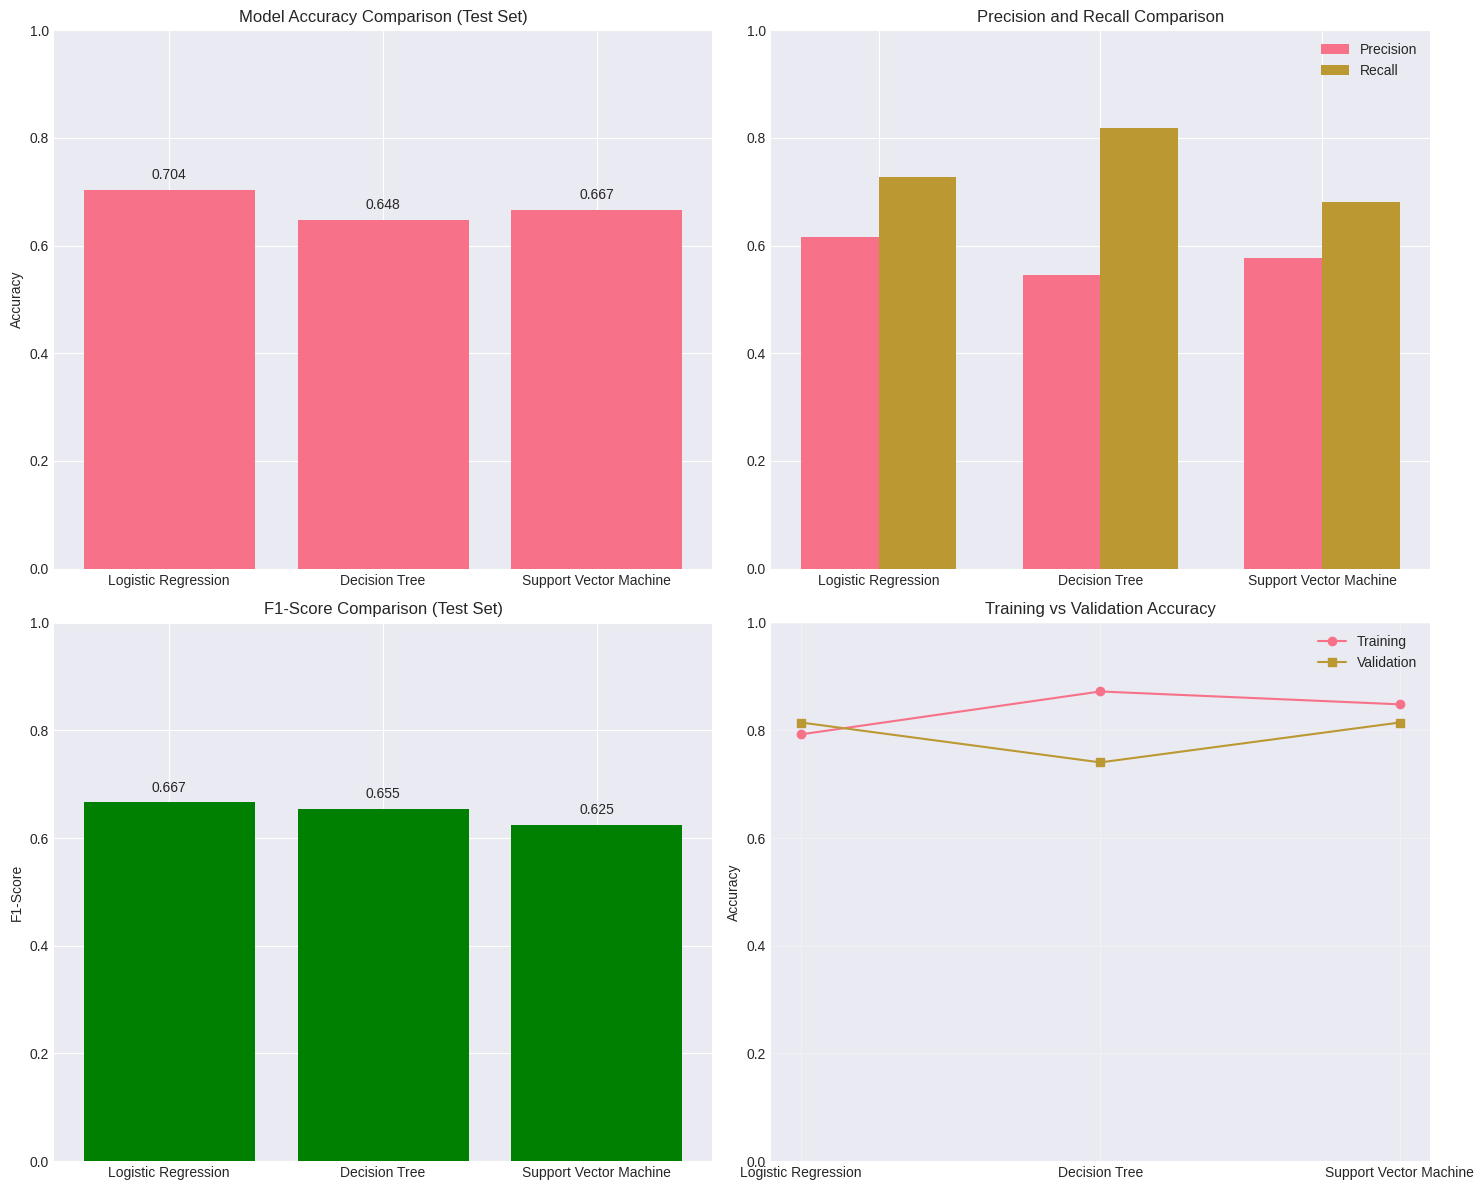

In [10]:
# ============================================
# 8. MODEL COMPARISON AND VISUALISATION
# ============================================

print("\n" + "="*50)
print("MODEL COMPARISON SUMMARY")
print("="*50)

# Create comparison DataFrame
comparison_data = []
for name in models.keys():
    comparison_data.append({
        'Model': name,
        'Train_Accuracy': next(r for r in all_results if r['model_name'] == name)['train_accuracy'],
        'Val_Accuracy': next(r for r in all_results if r['model_name'] == name)['val_accuracy'],
        'Test_Accuracy': test_results[name]['test_accuracy'],
        'Test_Precision': test_results[name]['test_precision'],
        'Test_Recall': test_results[name]['test_recall'],
        'Test_F1': test_results[name]['test_f1']
    })

comparison_df = pd.DataFrame(comparison_data)
print("\nModel Performance Comparison:")
print(comparison_df.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Accuracy Comparison
axes[0, 0].bar(comparison_df['Model'], comparison_df['Test_Accuracy'])
axes[0, 0].set_title('Model Accuracy Comparison (Test Set)')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_ylim([0, 1])
for i, v in enumerate(comparison_df['Test_Accuracy']):
    axes[0, 0].text(i, v + 0.02, f'{v:.3f}', ha='center')

# 2. Precision-Recall Comparison
x = np.arange(len(comparison_df['Model']))
width = 0.35
axes[0, 1].bar(x - width/2, comparison_df['Test_Precision'], width, label='Precision')
axes[0, 1].bar(x + width/2, comparison_df['Test_Recall'], width, label='Recall')
axes[0, 1].set_title('Precision and Recall Comparison')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(comparison_df['Model'])
axes[0, 1].legend()
axes[0, 1].set_ylim([0, 1])

# 3. F1-Score Comparison
axes[1, 0].bar(comparison_df['Model'], comparison_df['Test_F1'], color='green')
axes[1, 0].set_title('F1-Score Comparison (Test Set)')
axes[1, 0].set_ylabel('F1-Score')
axes[1, 0].set_ylim([0, 1])
for i, v in enumerate(comparison_df['Test_F1']):
    axes[1, 0].text(i, v + 0.02, f'{v:.3f}', ha='center')

# 4. Training vs Validation Accuracy
axes[1, 1].plot(comparison_df['Model'], comparison_df['Train_Accuracy'], 'o-', label='Training')
axes[1, 1].plot(comparison_df['Model'], comparison_df['Val_Accuracy'], 's-', label='Validation')
axes[1, 1].set_title('Training vs Validation Accuracy')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## **9. FEATURE IMPORTANCE ANALYSIS**
**Observation:**
Finally, feature importance is examined using the trained Decision Tree model to understand which input variables have the greatest influence on diabetes prediction. The importance scores indicate which features contribute most to the models decisions, improving transparency and interpretability. Visualising the most important features helps highlight key medical and lifestyle factors associated with diabetes and provides useful insights into the models behaviour.



FEATURE IMPORTANCE ANALYSIS

Feature Importance (Decision Tree):
                 feature  importance
                 Glucose    0.668359
           SkinThickness    0.104455
          Metabolic_Risk    0.098653
             Pregnancies    0.067005
DiabetesPedigreeFunction    0.061528
           BloodPressure    0.000000
                     BMI    0.000000
                 Insulin    0.000000
                     Age    0.000000
   PhysicalActivityLevel    0.000000
   FamilyHistory_encoded    0.000000
            High_Insulin    0.000000


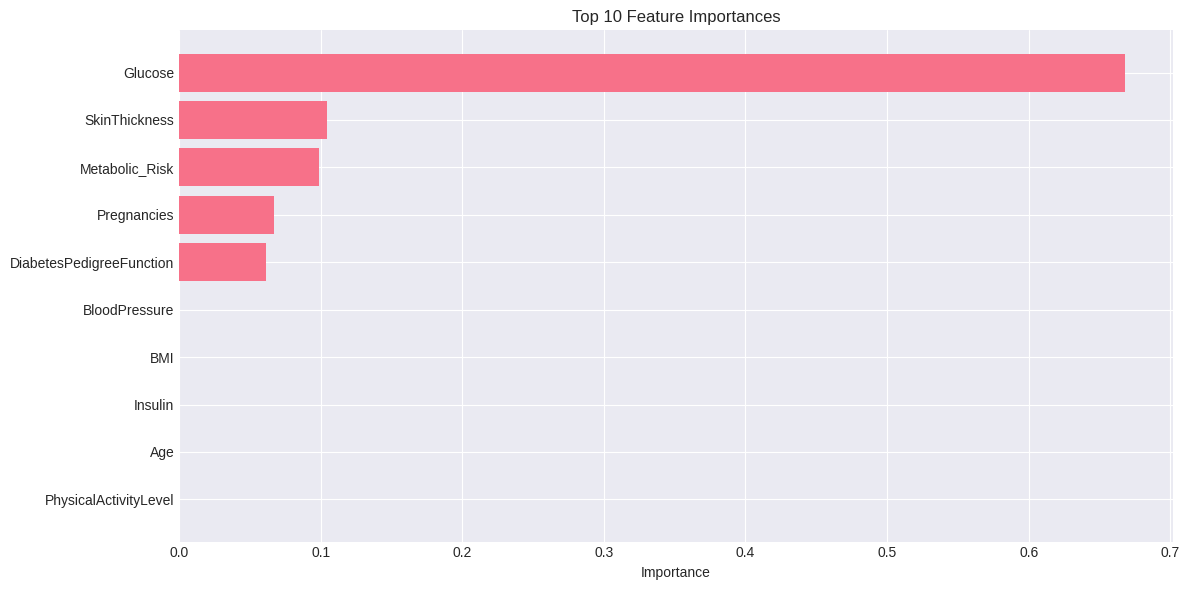

In [11]:
# ============================================
# 9. FEATURE IMPORTANCE ANALYSIS
# ============================================

print("\n" + "="*50)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*50)

# Get feature importance from Decision Tree
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_dt.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance (Decision Tree):")
print(feature_importance.to_string(index=False))

# Visualize feature importance
plt.figure(figsize=(12, 6))
plt.barh(feature_importance['feature'][:10], feature_importance['importance'][:10])
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()